# Week 2: Summer project

## SMBH-Galaxy Scaling Relations

Black hole mass MBH vs. stellar velocity dispersion σ

1. A plot of just the black hole masses and velocity dispersions
2. A plot of the above, but galaxies are separated by Method 
3. A plot of the above, but galaxies are separated by Morphological Type 

In [152]:
#This shows us how the columns are separated; in this case, columns are separated by \t. 
#Thus, we can visualize where we are working and therefore be able to delete unnecessary columns and rows. 
with open("apj459110t3_ascii.txt", "r") as f:
    for i, linea in enumerate(f):
        print(repr(linea))
        if i > 25:
            break 

'Table 3 \n'
'Galaxies with Dynamical Measurements of M_bull\n'
'\n'
'\n'
'Galaxy\tM_bull (+, -)\tRef.\tsigma\tlog L_V\tM_bulge\tRef.\t r_inf\tMorph.\tD\tMethod\t\n'
'\t( M_sun)\t\t( km s^-1)\t\t( M_sun)\t\t(")\t\t(Mpc)\t\t\n'
'Milky Way^a\t4.1 (0.6,0.6) e6\t1,2\t103 +or- 20\t\t\t\t43\tS\t0.008\tstars\t\n'
'A1836-BCG\t3.9 (0.4,0.6) e9\t3\t288 +or- 14\t11.26 +or- 0.06\t\t\t0.27\tE (C)\t157.5\tgas\t\n'
'A3565-BCG\t1.4 (0.3,0.2) e9\t3\t322 +or- 16\t11.24 +or- 0.06\t\t\t0.22\tE (C)\t54.4\tgas\t\n'
'Circinus\t1.7 (0.4,0.3) e6\t4\t158 +or- 18\t\t\t\t0.02\tS\t4.0\tmasers\t\n'
'IC 1459^b\t2.8 (1.1,1.2) e9\t5\t315 +or- 16\t10.96 +or- 0.06\t3.07e11\t45\t0.81\tE (C)\t30.9\tstars\t\n'
'N221 (M32)^y\t2.6 (0.5,0.5) e6\t6\t75 +or- 3\t8.52 +or- 0.02\t7.62e8\t45\t0.57\tE (I)\t0.73\tstars\t\n'
'N224 (M31)^y\t1.4 (0.8,0.3) e8\t7\t160 +or- 8\t\t\t\t6.5\tS\t0.73\tstars\t\n'
'N524^w\t8.6 (1.0,0.4) e8\t8\t235 +or- 12\t10.62 +or- 0.04\t\t\t0.57\tS0 (C)\t24.2\tstars\t\n'
'N821^w\t1.7 (0.7,0.7) e8\t9\t209 +or- 

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [154]:
df = pd.read_csv("apj459110t3_ascii.txt", sep="\t", skiprows=4, header=0)
df = df.drop(index=0).drop(columns=["Unnamed: 11"], errors="ignore").reset_index(drop=True)
#sep="\t" - this is telling us how the columns are separated.
#skiprows=4 - skips the first four rows, which are titles, descriptions, and empty lines.
#header=0 - The first line read is the header containing the column names.
#drop(index=0) - the first row is deleted since it's only units.
#drop(columns=["Unnamed: 11"] - removes an empty column that pandas created automatically.

#The problem is that in the table, the black hole mass and the values for sigma are not clean numbers, but rather a string with a specific format.
def parsear_mbh(valor):
    if pd.isna(valor): return None
    match = re.search(r"([\d.]+)\s*(?:\([^)]*\))?\s*e(\d+)", str(valor))
    if match:
        return float(match.group(1)) * 10**int(match.group(2))
    return None

def parsear_sigma(valor):
    if pd.isna(valor): return None
    match = re.match(r"([\d.]+)", str(valor).strip())
    return float(match.group(1)) if match else None

df["MBH_sol"]   = df["M_bull (+, -)"].apply(parsear_mbh)
df["sigma_num"] = df["sigma"].apply(parsear_sigma)

#On a logarithmic scale, everything is well distributed.
log_sigma = np.log10(df_clean["sigma_num"])
log_mbh   = np.log10(df_clean["MBH_sol"])

df.head(73) #If we don´t mention the 73 rows, it will print everything, including the description above, as they were part of the table.

,Galaxy,"M_bull (+, -)",Ref.,sigma,log L_V,M_bulge,Ref..1,r_inf,Morph.,D,Method,MBH_sol,sigma_num
0,Milky Way^a,"4.1 (0.6,0.6) e6","1,2",103 +or- 20,NaN,NaN,NaN,43,S,0.008,stars,4.100000e+06,103.0
1,A1836-BCG,"3.9 (0.4,0.6) e9",3,288 +or- 14,11.26 +or- 0.06,NaN,NaN,0.27,E (C),157.5,gas,3.900000e+09,288.0
2,A3565-BCG,"1.4 (0.3,0.2) e9",3,322 +or- 16,11.24 +or- 0.06,NaN,NaN,0.22,E (C),54.4,gas,1.400000e+09,322.0
3,Circinus,"1.7 (0.4,0.3) e6",4,158 +or- 18,NaN,NaN,NaN,0.02,S,4.0,masers,1.700000e+06,158.0
4,IC 1459^b,"2.8 (1.1,1.2) e9",5,315 +or- 16,10.96 +or- 0.06,3.07e11,45.0,0.81,E (C),30.9,stars,2.800000e+09,315.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,N7052,"4.0 (2.8,1.6) e8",42,266 +or- 13,10.92 +or- 0.04,3.50e11,45.0,0.07,E (C),70.9,gas,4.000000e+08,266.0
69,N7582,"5.5 (1.6,1.1) e7",43,156 +or- 19,NaN,NaN,NaN,0.09,S,22.3,gas,5.500000e+07,156.0
70,"N7619^b,^w","2.3 (1.2,0.1) e9",15,313 +or- 16,11.07 +or- 0.05,NaN,NaN,0.39,E (C),53.9,stars,2.300000e+09,313.0
71,N7768^b,"1.3 (0.5,0.4) e9",44,257 +or- 13,11.09 +or- 0.05,1.16e12,44.0,0.14,E (C),112.8,stars,1.300000e+09,257.0


## 1. M_BH vs sigma

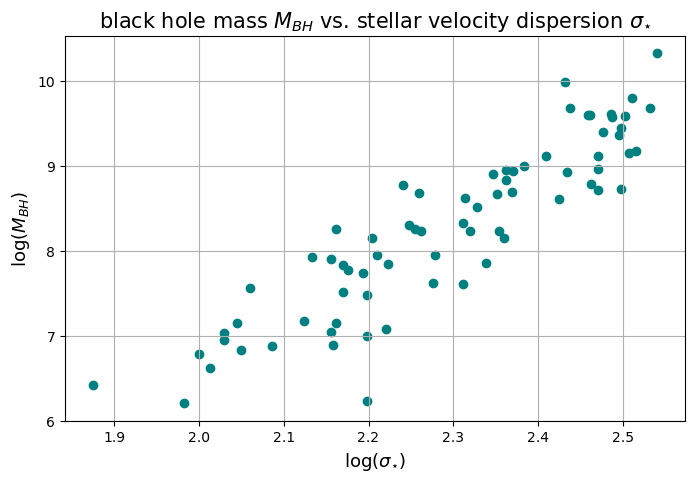

In [155]:
plt.figure(figsize=(8,5))
plt.xlabel('log($\sigma_{\star}$)', fontsize=13)
plt.ylabel('log($M_{BH}$)', fontsize=13)
plt.title('black hole mass $M_{BH}$ vs. stellar velocity dispersion $\sigma_{\star}$',fontsize=15)
plt.grid(True)
plt.scatter(log_sigma, log_mbh, color="teal")
plt.show()

## 2. M_BH vs. sigma (Galaxies are separated by Method)

In [156]:
df_clean["Method"].unique()

array(['stars', 'gas', 'masers'], dtype=object)

In [157]:
stars_idx = np.where(df_clean["Method"] == "stars")[0]
gas_idx = np.where(df_clean["Method"] == "gas")[0]
masers_idx = np.where(df_clean["Method"] == "masers")[0]

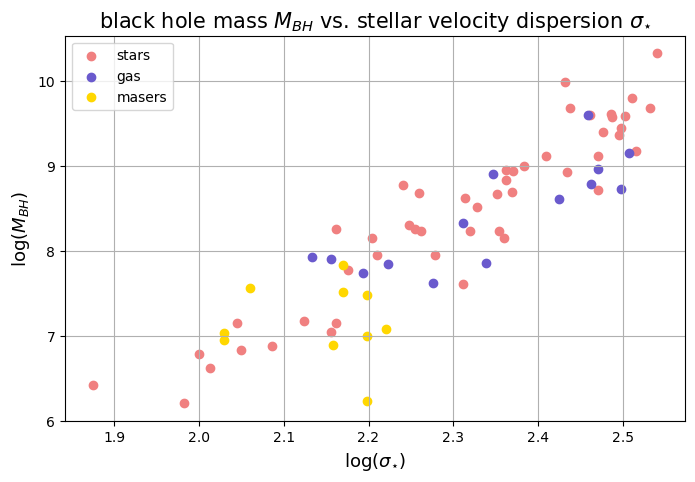

In [158]:
plt.figure(figsize=(8,5))
plt.xlabel('log($\sigma_{\star}$)', fontsize=13)
plt.ylabel('log($M_{BH}$)', fontsize=13)
plt.title('black hole mass $M_{BH}$ vs. stellar velocity dispersion $\sigma_{\star}$',fontsize=15)
plt.grid(True)
plt.scatter(log_sigma.iloc[stars_idx], log_mbh.iloc[stars_idx], label="stars", color="lightcoral")
plt.scatter(log_sigma.iloc[gas_idx], log_mbh.iloc[gas_idx], label="gas", color="slateblue")
plt.scatter(log_sigma.iloc[masers_idx], log_mbh.iloc[masers_idx], label="masers", color="gold")

plt.legend(fontsize=10)
plt.show()

## 3. M_BH vs. sigma (Galaxies are separated by Morphological Type)

In [159]:
df_clean["Morph."].unique()

array(['S', 'E (C)', 'E (I)', 'S0 (C)', 'S0 (pl)', 'S0', 'E (pl)',
       'S0 (I)', 'S0/E (C)'], dtype=object)

In [160]:
S_idx = np.where(df_clean["Morph."] == "S")[0]
EC_idx = np.where(df_clean["Morph."] == "E (C)")[0]
EI_idx = np.where(df_clean["Morph."] == "E (I)")[0]
S0C_idx = np.where(df_clean["Morph."] == "S0 (C)")[0]
S0pl_idx = np.where(df_clean["Morph."] == "S0 (pl)")[0]
Epl_idx = np.where(df_clean["Morph."] == "E (pl)")[0]
S0I_idx = np.where(df_clean["Morph."] == "S0 (I)")[0]
S0EC_idx = np.where(df_clean["Morph."] == "S0/E (C)")[0]

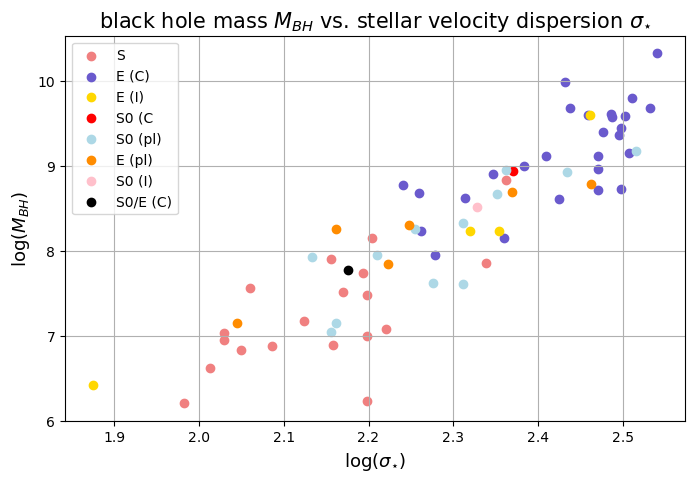

In [164]:
plt.figure(figsize=(8,5))
plt.xlabel('log($\sigma_{\star}$)', fontsize=13)
plt.ylabel('log($M_{BH}$)', fontsize=13)
plt.title('black hole mass $M_{BH}$ vs. stellar velocity dispersion $\sigma_{\star}$',fontsize=15)
plt.grid(True)
plt.scatter(log_sigma.iloc[S_idx], log_mbh.iloc[S_idx], label="S", color="lightcoral")
plt.scatter(log_sigma.iloc[EC_idx], log_mbh.iloc[EC_idx], label="E (C)", color="slateblue")
plt.scatter(log_sigma.iloc[EI_idx], log_mbh.iloc[EI_idx], label="E (I)", color="gold")
plt.scatter(log_sigma.iloc[S0C_idx], log_mbh.iloc[S0C_idx], label="S0 (C", color="red")
plt.scatter(log_sigma.iloc[S0pl_idx], log_mbh.iloc[S0pl_idx], label="S0 (pl)", color="lightblue")
plt.scatter(log_sigma.iloc[Epl_idx], log_mbh.iloc[Epl_idx], label="E (pl)", color="darkorange")
plt.scatter(log_sigma.iloc[S0I_idx], log_mbh.iloc[S0I_idx], label="S0 (I)", color="pink")
plt.scatter(log_sigma.iloc[S0EC_idx], log_mbh.iloc[S0EC_idx], label="S0/E (C)", color="black")


plt.legend(fontsize=10)
plt.show()